# Raport końcowy: reprezentacje ukrytych kart development w Catanie

Ten notebook jest samodzielnym podsumowaniem projektu na przedmiot **Uczenie Reprezentacji**. Zbiera wymagane elementy z polecenia: opis problemu, danych, modeli, eksperymentów, implementacji, decyzji projektowych, rezultatów oraz ograniczeń.

Projekt bada, czy sekwencyjne modele reprezentacji potrafią nauczyć się stanu przekonań o typach ukrytych kart development na podstawie publicznie obserwowalnej historii gry w Catanie.


In [ ]:
from pathlib import Path
import json

import pandas as pd
from IPython.display import Markdown, display, Image
    
ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()
RESULTS = ROOT / 'results'
FIGURES = RESULTS / 'figures'
DATA_SPLITS = ROOT / 'data' / 'splits'

pd.set_option('display.max_colwidth', 120)


def load_json(path):
    path = Path(path)
    if not path.exists():
        return None
    with path.open() as f:
        return json.load(f)


def show_missing(path, command=None):
    msg = f'Brak artefaktu: `{path}`.'
    if command:
        msg += f' Aby go odtworzyć, uruchom: `{command}`.'
    display(Markdown(msg))


artifacts = {
    'data/splits': DATA_SPLITS.exists(),
    'results/final_metrics.json': (RESULTS / 'final_metrics.json').exists(),
    'results/baseline_metrics.json': (RESULTS / 'baseline_metrics.json').exists(),
    'results/search_results.json': (RESULTS / 'search_results.json').exists(),
    'results/figures': FIGURES.exists(),
}

pd.DataFrame(
    [{'artefakt': k, 'dostępny lokalnie': 'tak' if v else 'nie'} for k, v in artifacts.items()]
)


,artefakt,dostępny lokalnie
0,data/splits,tak
1,results/final_metrics.json,tak
2,results/baseline_metrics.json,tak
3,results/search_results.json,tak
4,results/figures,tak


## Opis problemu

**Dane wejściowe.** Wejściem są sekwencje obserwacji publicznego stanu gry z perspektywy zewnętrznego obserwatora gry. Jedna sekwencja odpowiada parze `(game_id, observed_color)` i jest posortowana po `action_index`. Wektor obserwacji zawiera wyłącznie informacje dostępne publicznie: sumy zasobów, liczbę kart development na ręce, publiczne punkty, zagrane karty, budynki, drogi, aktualnego gracza, typ akcji, pozycję złodzieja oraz historię zakupów/zagrań kart development.

**Dane wyjściowe.** Dla każdej trzymanej karty development tworzymy osobną próbkę klasyfikacyjną. Etykietą jest prawdziwy typ karty: `KNIGHT`, `VICTORY_POINT`, `ROAD_BUILDING`, `MONOPOLY`, `YEAR_OF_PLENTY`.

**Typ zadania.** Jest to 5-klasowa klasyfikacja per karta z użyciem wyuczonej reprezentacji sekwencji gry. W propozycji projektu zapisano wariant 4-klasowy, ale w implementacji rozdzieliliśmy `MONOPOLY` i `YEAR_OF_PLENTY`, bo są osobnymi typami kart w talii i mają różną semantykę gry.

**Hipoteza badawcza.** Zakładaliśmy, że RSSM, dzięki rekurencyjnemu agregowaniu historii gry i jawnej separacji stanu deterministycznego oraz stochastycznego, da lepszą reprezentację niepewności niż VAE-LSTM, szczególnie w późniejszych fazach gry. Oczekiwaliśmy też, że modele reprezentacji poprawią wynik względem prostych reguł opartych na wiedzy dziedzinowej.


## Dane i przygotowanie zbioru

Dane są generowane samodzielnie w symulatorze `catanatron`. Generator zapisuje dwie powiązane tabele parquet:

| Tabela | Jednostka wiersza | Rola |
|---|---|---|
| `timesteps` | krok gry z perspektywy obserwowanego gracza | wejście sekwencyjne dla VAE/RSSM |
| `card_samples` | pojedyncza karta trzymana w danym kroku | próbka klasyfikacyjna z etykietą typu karty |

Łączenie odbywa się po `(game_id, observed_color, action_index)`. Split jest wykonywany per gra, żeby uniknąć przecieku między train/val/test. Gry z MCTS przy stole trafiają wyłącznie do testu jako przypadek `unseen_mcts`, a część gier bez MCTS tworzy test `seen`.

Najważniejsze decyzje przygotowania danych:

| Decyzja | Uzasadnienie |
|---|---|
| Obserwowany jest jeden gracz przy stole | Model ma uczyć stan przekonań o ukrytych kartach obserwowanego gracza z perspektywy zewnętrznego obserwatora. |
| Relatywne indeksowanie `p0..p3` | `p0` zawsze oznacza obserwowanego gracza, więc modele dostają spójny układ cech. |
| Wykluczenie `y_*` i ukrytych punktów VP z wejścia | Zapobiega bezpośredniemu przeciekowi targetu. |
| Osobna tabela `card_samples` | Jedna karta w jednym kroku to jedna próbka klasyfikacyjna. |
| Ewaluacja na startach tur | To moment decyzyjny, w którym informacja o niezagraniu karty ma sens interpretacyjny. |
| Izolacja MCTS w teście | Pozwala sprawdzić generalizację na niewidziany styl gry. |


## Opis modeli

### VAE-LSTM

Model bazuje na rodzinie VAE: Kingma i Welling, *Auto-Encoding Variational Bayes* (2013). W naszym wariancie enkoderem jest LSTM działający po sekwencji obserwacji. Dla każdego kroku generowany jest latent `z_t`, a dekoder rekonstruuje wektor obserwacji.

Dla obserwacji sekwencyjnej `x_{1:t}` enkoder LSTM wyznacza stan ukryty:

$$
h_t = \mathrm{LSTM}(x_t, h_{t-1})
$$

W wariancie Gaussowskim encoder parametryzuje posterior:

$$
q_\phi(z_t \mid x_{\le t}) = \mathcal{N}(\mu_t, \operatorname{diag}(\sigma_t^2))
$$

z próbkowaniem przez reparametryzację:

$$
z_t = \mu_t + \sigma_t \odot \epsilon, \qquad \epsilon \sim \mathcal{N}(0, I)
$$

Dekoder rekonstruuje obserwację:

$$
\hat{x}_t = p_\theta(x_t \mid z_t)
$$

Funkcja straty VAE:

$$
\mathcal{L}_{\mathrm{VAE}} =
\mathcal{L}_{\mathrm{recon}}(x_t, \hat{x}_t)
+ D_{\mathrm{KL}}\left(q_\phi(z_t \mid x_{\le t}) \;\|\; p(z_t)\right)
$$

W naszym wariancie Gaussowskim prior to:

$$
p(z_t) = \mathcal{N}(0, I)
$$

Wariant kategoryczny `vae_cat` zamiast rozkładu Gaussa używa zestawu zmiennych kategorycznych i KL względem stałego priora jednostajnego:

$$
D_{\mathrm{KL}}(q_\phi(z_t \mid x_{\le t}) \;\|\; \mathrm{Uniform})
$$

Do downstream probe trafia deterministyczna reprezentacja:

$$
e_t = \mu_t \quad \text{dla `vae`}
$$

albo wektor prawdopodobieństw kategorii dla `vae_cat`.

Warianty:

- `vae`: latent Gaussowski, probe używa deterministycznego `mu_t`.
- `vae_cat`: latent kategoryczny, KL względem stałego, jednostajnego priora.

### RSSM

RSSM opieramy na pracy Hafner et al. 2019, *Learning Latent Dynamics for Planning from Pixels* / PlaNet. Stan latentny składa się z deterministycznego stanu rekurencyjnego `h_t` i stochastycznego `z_t`.

Najpierw obserwacja jest mapowana do embeddingu:

$$
e_t = f_{\mathrm{emb}}(x_t)
$$

Deterministyczny stan historii aktualizowany jest przez GRU:

$$
h_t = \mathrm{GRU}(h_{t-1}, [z_{t-1}, e_t])
$$

RSSM uczy dwa rozkłady dla stochastycznego stanu:

$$
p_\theta(z_t \mid h_t) \quad \text{prior, przewidywany z historii}
$$

$$
q_\phi(z_t \mid h_t, e_t) \quad \text{posterior, korzystający z aktualnej obserwacji}
$$

Dekoder rekonstruuje obserwację z pełnego stanu latentnego:

$$
\hat{x}_t = p_\theta(x_t \mid h_t, z_t)
$$

Funkcja straty RSSM:

$$
\mathcal{L}_{\mathrm{RSSM}} =
\mathcal{L}_{\mathrm{recon}}(x_t, \hat{x}_t)
+ D_{\mathrm{KL}}\left(q_\phi(z_t \mid h_t, e_t) \;\|\; p_\theta(z_t \mid h_t)\right)
$$

Do downstream probe trafia konkatenacja deterministycznego i stochastycznego stanu:

$$
e^{\mathrm{probe}}_t = [h_t \;\Vert\; z_t]
$$

Warianty:

- `rssm_gauss`: Gaussowski stan stochastyczny i uczony prior.
- `rssm_cat`: kategoryczny stan stochastyczny inspirowany DreamerV2, z KL balancing i free bits.

Różnica względem VAE jest kluczowa: VAE porównuje posterior z prostym, stałym priorem, a RSSM uczy prior zależny od historii gry. Dzięki temu RSSM może modelować, jakie ukryte stany są spodziewane po dotychczasowym przebiegu partii.

### Modele nadzorowane i dodatkowe SSL

W repozytorium są też warianty supervised `*_supA/B/C` oraz wcześniejsza ścieżka Transformer SSL (`InfoNCE`, `Barlow Twins`, `MAE`). W finalnej interpretacji trzeba je traktować jako dodatkowe punkty odniesienia, a nie ten sam protokół co zamrożony encoder + linear probe.


## Opis eksperymentów

Główny protokół ewaluacyjny:

1. Uczymy reprezentację sekwencji na `timesteps`.
2. Zamrażamy encoder.
3. Dla każdej próbki-karty pobieramy embedding kroku i doklejamy jawne cechy per karta: `rounds_held`, `card_slot`, `n_hidden_cards`, `bought_at_action`, `current_rel_pos`.
4. Trenujemy głowicę/probe do klasyfikacji typu karty.
5. Raportujemy wyniki na TEST, osobno dla `seen`, `unseen_mcts` i `observed_type`.

Metryki:

- **macro-F1** jako metryka główna, ponieważ klasy są silnie niezbalansowane.
- F1 per klasa, aby pokazać zachowanie na rzadkich typach kart.
- Accuracy jako metryka pomocnicza.
- Przedziały ufności po seedach, gdy dostępne są wielokrotne uruchomienia.

Baseline końcowy to `src.baseline_heuristic`: nieuczony system reguł startujący od priora składu talii i aktualizujący go na podstawie jawnych sygnałów z gry. Logistic regression z EDA traktujemy jako pomocniczy baseline analityczny, nie jako główny baseline końcowy.


In [29]:
commands = pd.DataFrame([
    {
        'krok': 'Generowanie danych',
        'komenda': 'uv run generate_dataset_v2.py --num 10000 --out-dir data --workers 16 --chunk-size 1000',
        'wynik': 'data/timesteps_*.parquet, data/card_samples_*.parquet',
    },
    {
        'krok': 'Weryfikacja danych',
        'komenda': 'uv run verify_dataset.py --data-dir data',
        'wynik': 'kontrole integralności i braku przecieku',
    },
    {
        'krok': 'Split',
        'komenda': 'uv run split_dataset.py --data-dir data --out-dir data/splits',
        'wynik': 'train/val/test parquet',
    },
    {
        'krok': 'Search hiperparametrów',
        'komenda': 'uv run python -m src.search --subsample-games 1500 --epochs 8 --probe-games 1200',
        'wynik': 'results/search_results.json',
    },
    {
        'krok': 'Finalny trening',
        'komenda': 'uv run python -m src.train_final --families all --epochs 25 --seeds 0,1,2',
        'wynik': 'results/final_metrics.json, checkpointy final_*_seed*.pt',
    },
    {
        'krok': 'Baseline heurystyczny',
        'komenda': 'uv run python -m src.baseline_heuristic',
        'wynik': 'results/baseline_metrics.json',
    },
])
commands


,krok,komenda,wynik
0,Generowanie danych,uv run generate_dataset_v2.py --num 10000 --out-dir data --workers 16 --chunk-size 1000,"data/timesteps_*.parquet, data/card_samples_*.parquet"
1,Weryfikacja danych,uv run verify_dataset.py --data-dir data,kontrole integralności i braku przecieku
2,Split,uv run split_dataset.py --data-dir data --out-dir data/splits,train/val/test parquet
3,Search hiperparametrów,uv run python -m src.search --subsample-games 1500 --epochs 8 --probe-games 1200,results/search_results.json
4,Finalny trening,"uv run python -m src.train_final --families all --epochs 25 --seeds 0,1,2","results/final_metrics.json, checkpointy final_*_seed*.pt"
5,Baseline heurystyczny,uv run python -m src.baseline_heuristic,results/baseline_metrics.json


## Wyniki searcha konfiguracji

Przed finalnym treningiem uruchamiamy `src.search`, żeby wybrać konfiguracje na zbiorze walidacyjnym. Search używa krótszego budżetu niż finalny trening: podpróbkowane gry, mniej epok i pojedynczy seed. Wyniki służą do wyboru konfiguracji, a nie jako finalny rezultat projektu.

Czytelniejszy układ to najpierw **wyniki per rodzina**, bo wtedy widać wpływ hiperparametrów wewnątrz tej samej architektury. Dopiero po tych tabelach pokazujemy podsumowanie: najlepsza konfiguracja wybrana do finalnego treningu dla każdej rodziny.

Search: **29 konfiguracji**, budżet: **1500 gier**, **8 epok**, batch size **32**. Poniższe wyniki są walidacyjne i służą do wyboru konfiguracji do finalnego treningu.

### VAE Gaussian: wpływ pojemności latentu, liczby warstw i learning rate

,name,val_macro_f1,vae_latent_dim,vae_h_dim,vae_num_layers,vae_dropout,lr,train_seconds,eval_seconds
5,vae_z128_lr1e3,0.334,128.000000,256.000000,-,-,1e-03,5.4,5.6
3,vae_z128_2L,0.331,128.000000,256.000000,2.000000,0.100000,-,7.0,10.8
4,vae_z128_beta1,0.319,128.000000,256.000000,-,-,-,5.3,5.8
2,vae_z256,0.315,256.000000,256.000000,1.000000,-,-,6.0,36.0
1,vae_z128,0.294,128.000000,256.000000,1.000000,-,-,5.6,7.3
0,vae_z64,0.282,64.000000,256.000000,1.000000,-,-,6.4,2.3


### VAE Categorical: liczba zmiennych i klas latentnych

,name,val_macro_f1,vae_n_cat,vae_n_class,vae_h_dim,train_seconds,eval_seconds
8,vae_cat_16x16_beta1,0.307,16.000000,16.000000,256.000000,5.8,55.7
6,vae_cat_16x16,0.303,16.000000,16.000000,256.000000,5.7,55.5
7,vae_cat_32x32,0.294,32.000000,32.000000,256.000000,9.6,112.1


...

,name,val_macro_f1,rssm_n_cat,rssm_n_class,rssm_h_dim,rssm_kl_balance,train_seconds,eval_seconds
15,rssm_cat_16x16_klb0.5,0.303,16.000000,16.000000,128.000000,0.5,103.6,35.0
13,rssm_cat_16x16,0.297,16.000000,16.000000,128.000000,-,102.5,44.3
16,rssm_cat_24x24,0.287,24.000000,24.000000,200.000000,-,107.2,76.1
14,rssm_cat_32x32,0.285,32.000000,32.000000,200.000000,-,104.6,82.7


### Warianty supervised A/B/C

,family,base,mode,name,val_macro_f1,vae_latent_dim,vae_n_cat,vae_n_class,rssm_h_dim,rssm_z_dim,rssm_n_cat,rssm_n_class,train_seconds,eval_seconds
26,rssm_cat_supA,rssm_cat,A,rssm_cat_supA,0.315,-,-,-,128.000000,-,16.000000,16.000000,104.1,2.6
27,rssm_cat_supB,rssm_cat,B,rssm_cat_supB,0.243,-,-,-,128.000000,-,16.000000,16.000000,47.4,2.7
28,rssm_cat_supC,rssm_cat,C,rssm_cat_supC,0.224,-,-,-,128.000000,-,16.000000,16.000000,47.1,2.7
23,rssm_gauss_supA,rssm_gauss,A,rssm_gauss_supA,0.271,-,-,-,128.000000,128.000000,-,-,72.7,2.3
24,rssm_gauss_supB,rssm_gauss,B,rssm_gauss_supB,0.194,-,-,-,128.000000,128.000000,-,-,31.8,2.6
25,rssm_gauss_supC,rssm_gauss,C,rssm_gauss_supC,0.129,-,-,-,128.000000,128.000000,-,-,32.0,2.4
17,vae_supA,vae,A,vae_supA,0.340,128.000000,-,-,-,-,-,-,7.8,0.8
18,vae_supB,vae,B,vae_supB,0.100,128.000000,-,-,-,-,-,-,3.2,0.9
19,vae_supC,vae,C,vae_supC,0.121,128.000000,-,-,-,-,-,-,3.2,0.8
20,vae_cat_supA,vae_cat,A,vae_cat_supA,0.277,-,16.000000,16.000000,-,-,-,-,8.0,1.0


## Podsumowanie searcha: najlepsza konfiguracja per rodzina

,family,selected_config,val_macro_f1,overrides
0,vae_supA,vae_supA,0.340,"{""vae_latent_dim"": 128, ""vae_h_dim"": 256}"
1,vae,vae_z128_lr1e3,0.334,"{""vae_latent_dim"": 128, ""vae_h_dim"": 256, ""lr"": 0.001}"
2,rssm_gauss,rssm_gauss_h64,0.328,"{""rssm_h_dim"": 64, ""rssm_z_dim"": 64}"
3,rssm_cat_supA,rssm_cat_supA,0.315,"{""rssm_n_cat"": 16, ""rssm_n_class"": 16, ""rssm_h_dim"": 128}"
4,vae_cat,vae_cat_16x16_beta1,0.307,"{""vae_n_cat"": 16, ""vae_n_class"": 16, ""vae_h_dim"": 256, ""vae_beta_max"": 1.0}"
5,rssm_cat,rssm_cat_16x16_klb0.5,0.303,"{""rssm_n_cat"": 16, ""rssm_n_class"": 16, ""rssm_h_dim"": 128, ""rssm_kl_balance"": 0.5}"
6,vae_cat_supA,vae_cat_supA,0.277,"{""vae_n_cat"": 16, ""vae_n_class"": 16, ""vae_h_dim"": 256}"
7,rssm_gauss_supA,rssm_gauss_supA,0.271,"{""rssm_h_dim"": 128, ""rssm_z_dim"": 128}"
8,rssm_cat_supB,rssm_cat_supB,0.243,"{""rssm_n_cat"": 16, ""rssm_n_class"": 16, ""rssm_h_dim"": 128}"
9,rssm_cat_supC,rssm_cat_supC,0.224,"{""rssm_n_cat"": 16, ""rssm_n_class"": 16, ""rssm_h_dim"": 128}"


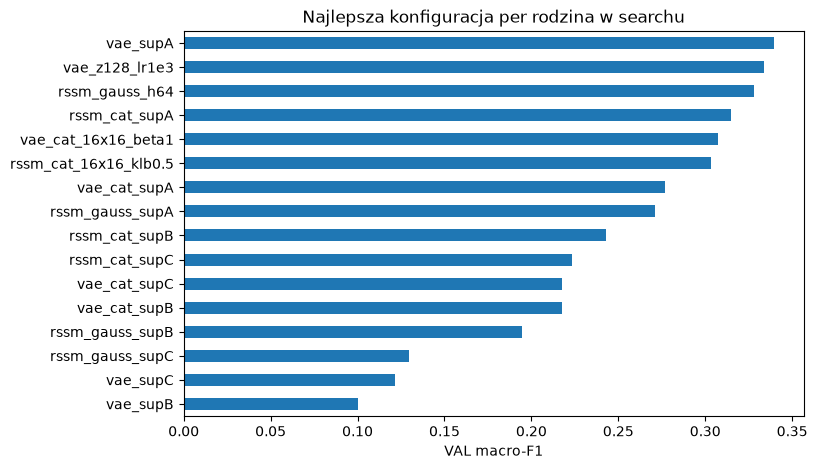

In [30]:
search_path = RESULTS / 'search_results.json'
search_results = load_json(search_path)

if search_results is None:
    show_missing(search_path, 'uv run python -m src.search --subsample-games 1500 --epochs 8 --probe-games 1200')
else:
    rows = []
    for row in search_results.get('results', []):
        overrides = row.get('overrides', {}) or {}
        flat = {
            'name': row.get('name'),
            'family': row.get('family'),
            'val_macro_f1': row.get('val_macro_f1'),
            'train_seconds': row.get('train_seconds'),
            'eval_seconds': row.get('eval_seconds'),
            'est_final_seconds': row.get('est_final_seconds'),
        }
        flat.update(overrides)
        rows.append(flat)

    df_search = pd.DataFrame(rows).sort_values(['family', 'val_macro_f1'], ascending=[True, False], na_position='last')
    cfg_search = search_results.get('config', {})
    display(Markdown(
        f"Search: **{len(df_search)} konfiguracji**, budżet: **{cfg_search.get('subsample_games', '?')} gier**, "
        f"**{cfg_search.get('epochs', '?')} epok**, batch size **{cfg_search.get('batch_size', '?')}**. "
        "Poniższe wyniki są walidacyjne i służą do wyboru konfiguracji do finalnego treningu."
    ))

    def show_family(family, cols, title=None):
        sub = df_search[df_search['family'] == family].copy()
        if sub.empty:
            return
        cols = [c for c in cols if c in sub.columns]
        shown = sub[['name', 'val_macro_f1'] + cols + ['train_seconds', 'eval_seconds']]
        display(Markdown(f"### {title or family}"))
        display(
            shown
            .style.format({
                'val_macro_f1': '{:.3f}',
                'train_seconds': '{:.1f}',
                'eval_seconds': '{:.1f}',
                'lr': '{:.0e}',
                'rssm_kl_balance': '{:.2g}',
            }, na_rep='-')
            .background_gradient(cmap='cividis', subset=['val_macro_f1'])
            .set_caption('Konfiguracje posortowane wg VAL macro-F1')
        )

    show_family(
        'vae',
        ['vae_latent_dim', 'vae_h_dim', 'vae_num_layers', 'vae_dropout', 'lr'],
        'VAE Gaussian: wpływ pojemności latentu, liczby warstw i learning rate',
    )
    show_family(
        'vae_cat',
        ['vae_n_cat', 'vae_n_class', 'vae_h_dim'],
        'VAE Categorical: liczba zmiennych i klas latentnych',
    )
    show_family(
        'rssm_gauss',
        ['rssm_h_dim', 'rssm_z_dim', 'lr'],
        'RSSM Gaussian: rozmiar stanu deterministycznego i stochastycznego',
    )
    show_family(
        'rssm_cat',
        ['rssm_n_cat', 'rssm_n_class', 'rssm_h_dim', 'rssm_kl_balance'],
        'RSSM Categorical: dyskretny latent i KL balancing',
    )

    sup_families = [f for f in df_search['family'].dropna().unique() if '_sup' in f]
    if sup_families:
        display(Markdown('### Warianty supervised A/B/C'))
        sup = df_search[df_search['family'].isin(sup_families)].copy()
        sup[['base', 'mode']] = sup['family'].str.extract(r'(.+)_sup([ABC])')
        sup_cols = ['family', 'base', 'mode', 'name', 'val_macro_f1',
                    'vae_latent_dim', 'vae_n_cat', 'vae_n_class',
                    'rssm_h_dim', 'rssm_z_dim', 'rssm_n_cat', 'rssm_n_class',
                    'train_seconds', 'eval_seconds']
        sup_cols = [c for c in sup_cols if c in sup.columns]
        display(
            sup[sup_cols].sort_values(['base', 'mode', 'val_macro_f1'], ascending=[True, True, False])
            .style.format({
                'val_macro_f1': '{:.3f}',
                'train_seconds': '{:.1f}',
                'eval_seconds': '{:.1f}',
            }, na_rep='-')
            .background_gradient(cmap='cividis', subset=['val_macro_f1'])
            .set_caption('Supervised: A=frozen SSL+MLP, B=CE+KL, C=CE+KL+rekonstrukcja')
        )

    display(Markdown('## Podsumowanie searcha: najlepsza konfiguracja per rodzina'))
    best = search_results.get('best_per_family', {})
    by_name = {row['name']: row for row in search_results.get('results', [])}
    best_rows = []
    for family, name in best.items():
        row = by_name.get(name, {})
        overrides = row.get('overrides', {}) or {}
        best_rows.append({
            'family': family,
            'selected_config': name,
            'val_macro_f1': row.get('val_macro_f1'),
            'overrides': json.dumps(overrides, ensure_ascii=False),
        })

    df_best = pd.DataFrame(best_rows).sort_values('val_macro_f1', ascending=False, na_position='last')
    display(
        df_best
        .style.format({'val_macro_f1': '{:.3f}'}, na_rep='-')
        .background_gradient(cmap='viridis', subset=['val_macro_f1'])
        .set_caption('Konfiguracje wybrane do finalnego treningu per rodzina')
    )

    ax = df_best.sort_values('val_macro_f1').plot(
        kind='barh', x='selected_config', y='val_macro_f1', figsize=(8, 5), legend=False
    )
    ax.set_xlabel('VAL macro-F1')
    ax.set_ylabel('')
    ax.set_title('Najlepsza konfiguracja per rodzina w searchu')


## Wyniki główne

Poniższa komórka ładuje finalne metryki, jeśli zostały wygenerowane. Jeśli artefaktów nie ma lokalnie, notebook pozostaje czytelny i wskazuje, które komendy trzeba uruchomić.


In [31]:
def rows_from_final_metrics(data, source):
    rows = []
    if not data or 'final' not in data:
        return rows
    for model, payload in data['final'].items():
        summary = payload.get('summary', {})
        all_metrics = summary.get('all') or {}
        seen_metrics = summary.get('seen') or {}
        unseen_metrics = summary.get('unseen_mcts') or {}
        rows.append({
            'model': model,
            'źródło': source,
            'typ': 'supervised' if '_sup' in model else ('heuristic' if model == 'heuristic' else 'representation'),
            'macro_f1_all': all_metrics.get('mean'),
            'ci95_all': all_metrics.get('ci95'),
            'macro_f1_seen': seen_metrics.get('mean'),
            'macro_f1_unseen_mcts': unseen_metrics.get('mean'),
            'n_seeds': all_metrics.get('n_seeds'),
        })
    return rows

final_metrics = load_json(RESULTS / 'final_metrics.json')
baseline_metrics = load_json(RESULTS / 'baseline_metrics.json')
rows = rows_from_final_metrics(final_metrics, 'train_final') + rows_from_final_metrics(baseline_metrics, 'baseline_heuristic')

if not rows:
    show_missing(RESULTS / 'final_metrics.json', 'uv run python -m src.train_final --families all --epochs 25 --seeds 0,1,2')
    show_missing(RESULTS / 'baseline_metrics.json', 'uv run python -m src.baseline_heuristic')
else:
    df_results = pd.DataFrame(rows).drop_duplicates(subset=['model'], keep='last')
    df_results = df_results.sort_values('macro_f1_all', ascending=False, na_position='last')
    display(df_results)


,model,źródło,typ,macro_f1_all,ci95_all,macro_f1_seen,macro_f1_unseen_mcts,n_seeds
14,vae_supB,train_final,supervised,0.312174,0.017982,0.350904,0.305663,3
16,heuristic,baseline_heuristic,heuristic,0.300696,0.000000,0.280272,0.300688,1
4,rssm_gauss,train_final,representation,0.296051,0.016490,0.319671,0.290352,3
1,rssm_cat_supA,train_final,supervised,0.291328,0.032252,0.307202,0.289504,3
9,vae_cat,train_final,representation,0.285863,0.011496,0.323326,0.277042,3
2,rssm_cat_supB,train_final,supervised,0.283243,0.037355,0.347256,0.273548,3
0,rssm_cat,train_final,representation,0.280258,0.002100,0.320529,0.272898,3
15,vae_supC,train_final,supervised,0.276122,0.024340,0.337262,0.267216,3
6,rssm_gauss_supB,train_final,supervised,0.275440,0.011863,0.318133,0.268522,3
3,rssm_cat_supC,train_final,supervised,0.269461,0.047036,0.325981,0.261457,3


### `rep_ranking.png`

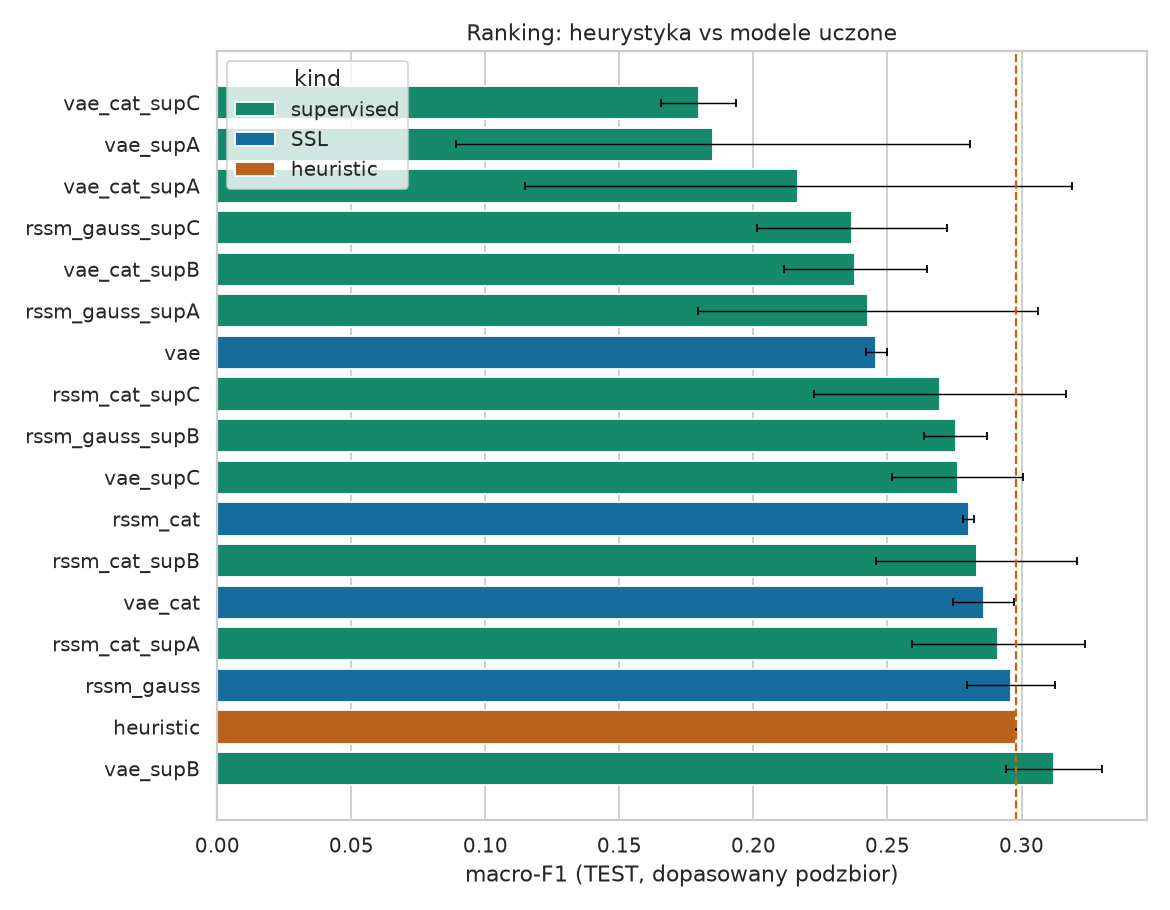

### `rep_observed_type.png`

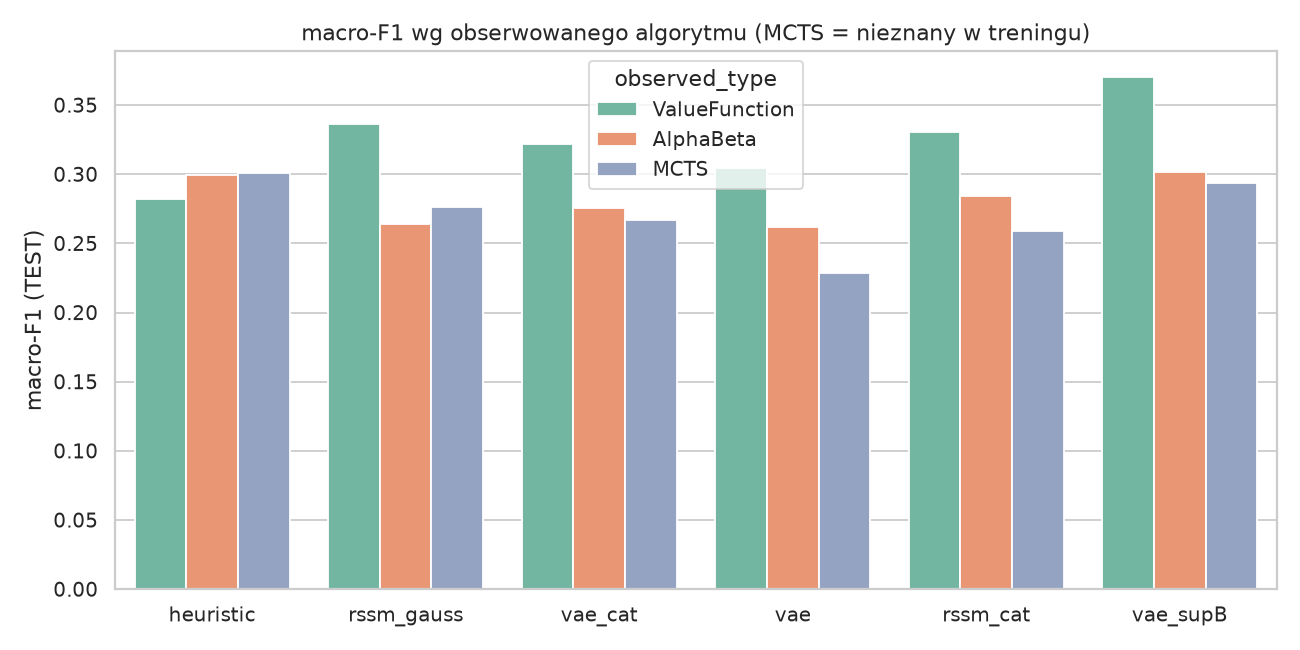

### `rep_perclass.png`

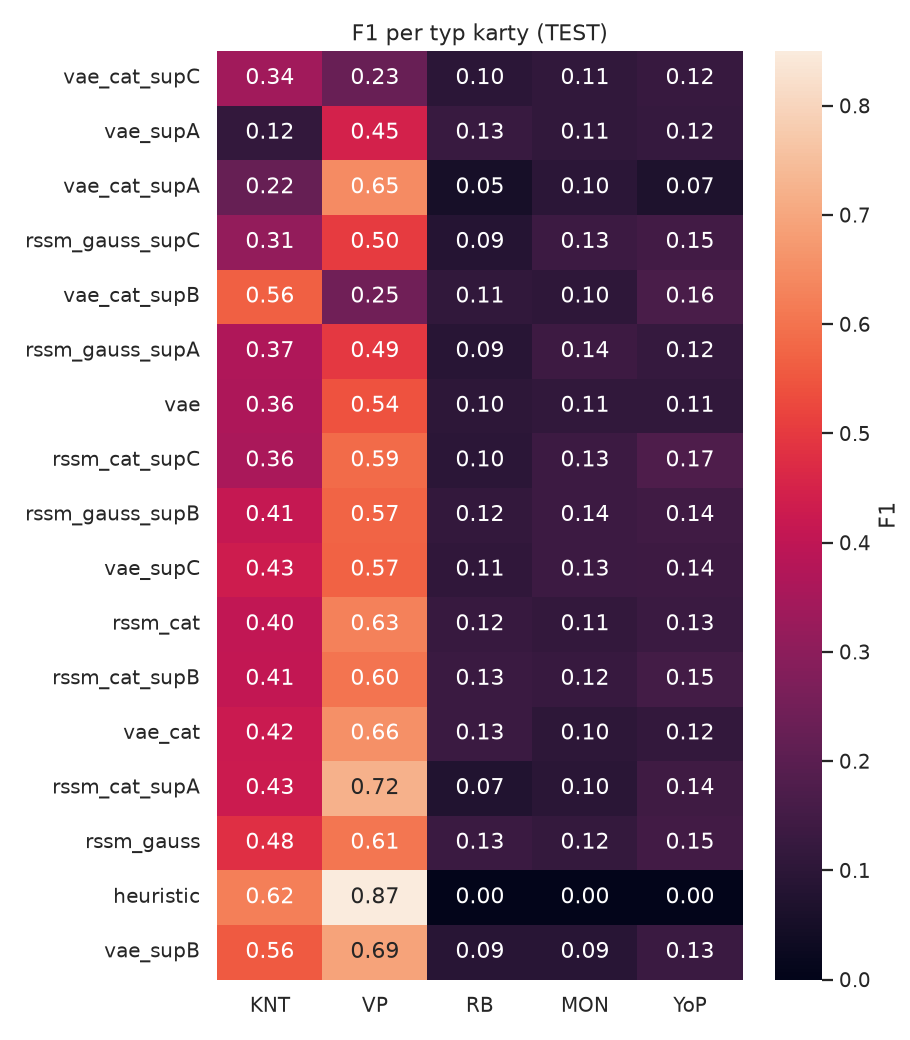

### `rep_confusion.png`

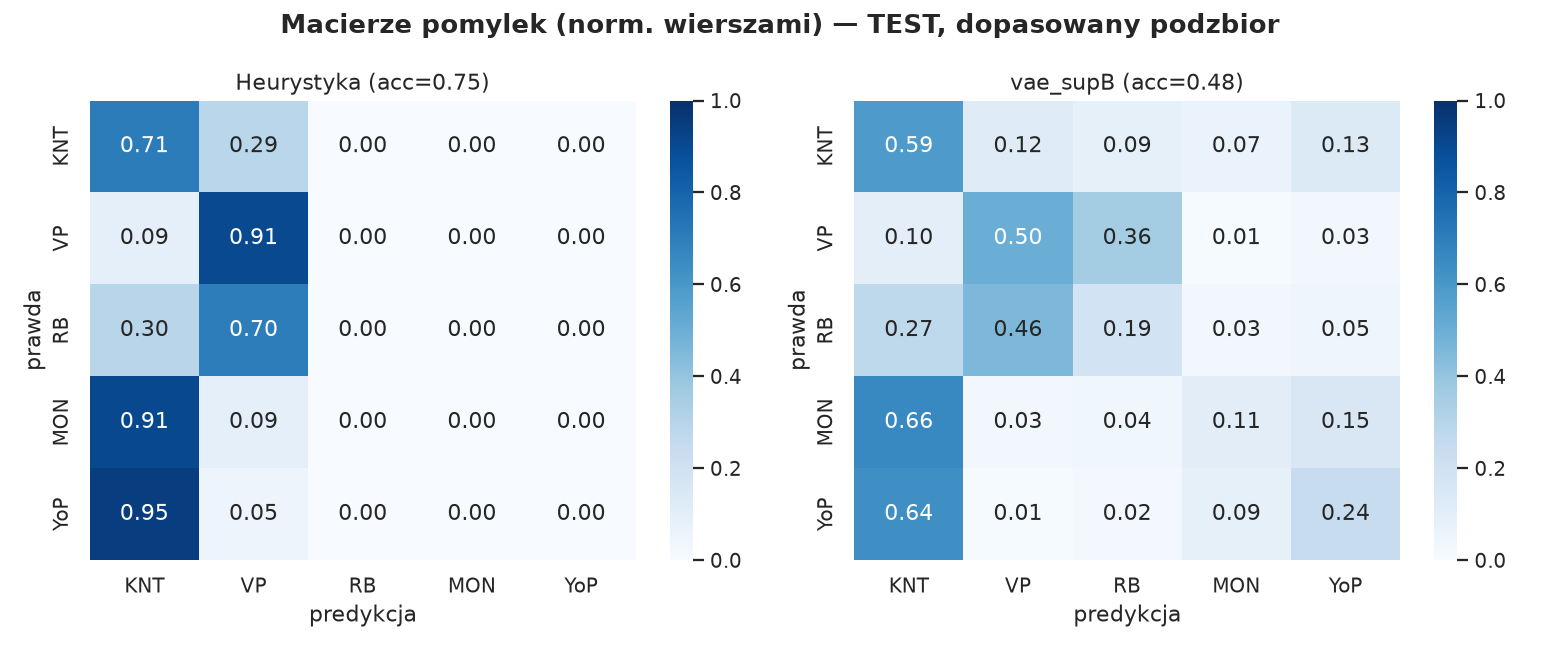

In [32]:
figure_files = [
    'rep_ranking.png',
    'rep_observed_type.png',
    'rep_perclass.png',
    'rep_confusion.png',
]

shown = False
for name in figure_files:
    path = FIGURES / name
    if path.exists():
        display(Markdown(f'### `{name}`'))
        display(Image(filename=str(path)))
        shown = True
if not shown:
    show_missing(FIGURES, 'uruchom notebooks/03_vae_rssm.ipynb oraz notebooks/04_final_report.ipynb po wygenerowaniu results/')


## Interpretacja wyników i hipotezy

Wyniki należy interpretować ostrożnie, bo finalna ewaluacja modeli uczonych korzysta z `eval_seq_len=512`, co może ograniczać pokrycie późnej fazy gry. To jest szczególnie ważne dla naszej hipotezy, która dotyczyła przewagi RSSM w agregowaniu długiej historii.

Najważniejsze wnioski projektowe:

- Hipoteza o jednoznacznej przewadze RSSM nad VAE nie została silnie potwierdzona. Różnice między rodzinami VAE/RSSM są małe i zależne od wariantu latentnego oraz protokołu ewaluacji.
- Heurystyka jest mocnym punktem odniesienia, bo wykorzystuje zasady gry, których modele muszą nauczyć się pośrednio z sekwencji.
- Rzadkie klasy `MONOPOLY` i `YEAR_OF_PLENTY` pozostają najtrudniejsze, co jest zgodne z dużą nierównowagą klas.
- Modele uczone gorzej generalizują na `MCTS`, jeśli ten styl był izolowany w teście.
- Warianty supervised mogą osiągać lepsze wyniki, ale nie są tym samym eksperymentem co zamrożona reprezentacja + linear probe.

Ponieważ dataset jest własny, nie raportujemy zewnętrznego state of the art. Zamiast tego porównujemy do baseline’u heurystycznego i prostszych punktów odniesienia.


## Decyzje projektowe

| Obszar | Decyzja | Konsekwencja |
|---|---|---|
| Jednostka próbki | pojedyncza karta w konkretnym kroku | Możemy oceniać F1 per typ karty. |
| Reprezentacja wejścia | tylko publiczne cechy, bez `y_*` | Brak przecieku targetu. |
| Split | per gra, MCTS izolowany w teście | Testuje generalizację na niewidziany styl. |
| Metryka główna | macro-F1 | Nie premiuje dominującej klasy kosztem rzadkich kart. |
| Baseline końcowy | nieuczony baseline heurystyczny | Interpretowalne odniesienie dla modeli reprezentacji. |
| VAE | LSTM + wariacyjny bottleneck | Prosty sekwencyjny model latentny do porównania z RSSM. |
| RSSM | GRU `h_t` + stochastyczne `z_t` | Model jawnie uczy dynamikę stanu przekonań. |
| Prezentacja wyników | oddzielenie SSL/probe od supervised | Unika mylenia różnych protokołów uczenia. |


## Ograniczenia i dalsze prace

- `eval_seq_len=512` ogranicza pełne testowanie hipotezy o późnej fazie gry; najlepiej powtórzyć ekstrakcję embeddingów z dłuższym limitem lub streamingowym RSSM.
- Rzadkie klasy wymagają większej liczby gier albo metod przeciwdziałania ekstremalnej nierównowadze.
- Wyniki supervised i SSL/probe należy raportować osobno, bo odpowiadają na różne pytania.
- Baseline heurystyczny nie pozwala na predykcję mniej reprezentowanych kart - YoP/RB/MON.
- Brak publicznego benchmarku oznacza, że porównania są wewnątrzprojektowe.
- F1-score nie jest idealną metryką. W zadaniu predykcji ukrytej karty ważne są wyniki procentowe dla każdej z klas - F1-Score bazuje tylko na argmaxie.
